# Benchmark: Constraint Mode Comparison

Compares the five constraint configurations on the same deformation fields:

| Mode | Flags |
|------|-------|
| **Jacobian only** | default |
| **Jacobian + Shoelace** | `enforce_shoelace=True` |
| **Jacobian + Triangulated** | `enforce_shoelace_triangulated=True` (strictly stronger than shoelace) |
| **Jacobian + Injectivity** | `enforce_injectivity=True` |
| **All constraints** | all three flags `True` |

Metrics: runtime, L2 error, final min Jdet, SLSQP iterations (outer), and
whether all negative Jacobians were eliminated.



## L-BFGS-B Optimizer Formulation

Two-phase **penalty → log-barrier continuation** minimised with `scipy.optimize.minimize(method="L-BFGS-B")` using analytic gradients (`jac=True`).

**Variables.** Flat vector $u = [d_x, d_y, d_z]$ of length $3 \cdot D \cdot H \cdot W$. Jacobian of the deformation $y = x + u(x)$ at voxel $i$:

$$J_i(u) = \det\bigl(I + \nabla u_i\bigr)$$

computed with `np.gradient` (central differences interior, one-sided at boundaries).

### Phase 1 — quadratic exterior penalty

$$F_\lambda(u) = \tfrac{1}{2}\|u - u_0\|^2 \;+\; \lambda \sum_{i \in \mathcal{A}} \bigl[\max\bigl(0,\ (\tau + \delta) - J_i(u)\bigr)\bigr]^2$$

Smooth ($C^1$), drives $u$ into the feasible interior. Continuation schedule: $\lambda \in \{1, 10, 10^2, \dots, 10^8\}$.

### Phase 2 — log barrier

$$F_\mu(u) = \tfrac{1}{2}\|u - u_0\|^2 \;-\; \mu \sum_{i \in \mathcal{A}} \log\bigl(J_i(u) - \tau\bigr)$$

Requires strict feasibility on $\mathcal{A}$ (returns $+\infty$ on infeasible iterates so the line search rejects the step). Continuation schedule: $\mu \in \{10^{-1}, 10^{-2}, 10^{-3}, 10^{-4}\}$.

### Symbols

| Symbol | Meaning |
|---|---|
| $u_0$ | Input field (data-term anchor) |
| $\tau$ | Jdet threshold (default $0.01$) |
| $\delta$ | Phase-1 target slack (default $10^{-3}$) |
| $\mathcal{A}$ | Active voxel mask (excludes frozen rim in windowed mode) |

### Gradient

Closed-form via the chain rule. The key term $(\partial J / \partial u)^\top v$ is computed as the **adjoint of `np.gradient`** applied to cofactor-weighted residuals — mathematically equivalent to the per-voxel Jacobian transpose product, but vectorised and $O(N)$.

### Windowed variant

For each connected component of $\{J \leq \tau - \varepsilon\}$: extract a bbox padded by `pad` voxels, pin the rim via L-BFGS-B `bounds = (v, v)`, restrict the sum to the non-frozen interior, and re-anchor the data term to the current patch state (matching SLSQP's windowed sub-solve).
Paste into a Jupyter markdown cell — LaTeX renders via MathJax.





In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import time

import matplotlib.pyplot as plt
import numpy as np
from benchmark_utils import (
    get_output_dir,
    log_run_footer,
    log_run_header,
    reset_figure_counter,
    results_to_rows,
    save_results_csv,
    save_summary_json,
    show_and_save,
)

from dvfopt import (
    iterative_serial,
    jacobian_det2D,
    shoelace_det2D,
)
from dvfopt.jacobian import (
    _diagonal_monotonicity_diffs_2d,
    _monotonicity_diffs_2d,
    triangulated_shoelace_det2D,
)
from dvfopt.jacobian.intersection import has_quad_self_intersections
from dvfopt.viz import plot_grid_before_after
from test_cases import SYNTHETIC_CASES, make_deformation, make_random_dvf

In [2]:
METHOD = "slsqp"
NOTEBOOK_NAME = "constraint-modes"
OUTPUT_DIR = get_output_dir(METHOD, NOTEBOOK_NAME, base="../../output")
reset_figure_counter()
summary = log_run_header(METHOD, NOTEBOOK_NAME, OUTPUT_DIR)


  Benchmark  : constraint-modes
  Method     : slsqp
  Timestamp  : 2026-04-17T11:31:12
  Output dir : ..\..\output\slsqp\constraint-modes


## Constraint modes

In [3]:
# ── Solver ───────────────────────────────────────────────────────────────────
# Switch between iterative_serial (safer, single-process) and
# iterative_parallel (faster on multi-core, avoids Windows spawn overhead
# for single-window cases).
SOLVER = iterative_serial
# SOLVER = iterative_parallel

# ── Jdet colormap cap ─────────────────────────────────────────────────────
# Values beyond ±JDET_VMAX are clamped so extreme outliers don't wash out
# the colour scale around zero.
JDET_VMAX = 10

# ── Injectivity threshold ─────────────────────────────────────────────────
# Explicit threshold bypasses the adaptive doubling loop (which reruns the
# full solver up to max_doublings+1 times).  Set to None to use adaptive.
INJECTIVITY_THRESHOLD = 0.3


In [4]:
MODES = {
    "Jacobian only":       {"enforce_shoelace": False, "enforce_injectivity": False},
    "Jac + Shoelace":      {"enforce_shoelace": True,  "enforce_injectivity": False},
    "Jac + Triangulated":  {"enforce_shoelace_triangulated": True},
    "Jac + Injectivity":   {"enforce_shoelace": False, "enforce_injectivity": True,
                            "injectivity_threshold": INJECTIVITY_THRESHOLD},
    "All constraints":     {"enforce_shoelace": True,  "enforce_injectivity": True,
                            "enforce_shoelace_triangulated": True,
                            "injectivity_threshold": INJECTIVITY_THRESHOLD},
}


## Helper: run one test case across all modes

In [5]:
from matplotlib.colors import TwoSlopeNorm


def _injectivity_stats(phi):
    """Compute shoelace, triangulated-shoelace, h/v/d1/d2 monotonicity
    violation counts and global intersection."""
    shoe = np.squeeze(shoelace_det2D(phi))
    T1, T2 = triangulated_shoelace_det2D(phi)
    tri_min = np.minimum(np.squeeze(T1), np.squeeze(T2))
    h_m, v_m = _monotonicity_diffs_2d(phi[0], phi[1])
    d1, d2   = _diagonal_monotonicity_diffs_2d(phi[0], phi[1])
    # Global check: any non-adjacent quad cells intersect geometrically?
    # O(n^2) — slow on large grids but definitive.
    global_intersect = has_quad_self_intersections(phi)
    return dict(
        n_neg_shoe       = int((shoe[1:-1, 1:-1] <= 0).sum()),
        n_neg_tri        = int((tri_min[1:-1, 1:-1] <= 0).sum()),
        n_h_viol         = int((h_m[1:-1, 1:-1] <= 0).sum()),
        n_v_viol         = int((v_m[1:-1, 1:-1] <= 0).sum()),
        n_d1_viol        = int((d1[1:-1, 1:-1] <= 0).sum()),
        n_d2_viol        = int((d2[1:-1, 1:-1] <= 0).sum()),
        global_intersect = global_intersect,
    )


def _plot_jdet_before_after(jac_before, jac_after, title, jdet_vmax=None):
    """Side-by-side Jdet heatmaps sharing a diverging colour scale centred at 0."""
    jb = np.squeeze(jac_before)
    ja = np.squeeze(jac_after)
    j_all = np.concatenate([jb.ravel(), ja.ravel()])
    vmin = min(float(j_all.min()), -0.5)
    vmax = max(float(j_all.max()),  1.5)
    if jdet_vmax is not None:
        vmin = max(vmin, -jdet_vmax)
        vmax = min(vmax,  jdet_vmax)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for ax, j, sub in [(axes[0], jb, "Initial"), (axes[1], ja, "Corrected")]:
        im = ax.imshow(j, cmap="bwr", norm=norm, interpolation="nearest")
        neg = int((j <= 0).sum())
        ax.set_title(f"{sub} — neg Jdet = {neg}, min = {float(j.min()):+.4f}",
                     fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=axes, label="Jacobian determinant", shrink=0.85)
    if title:
        fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)
    plt.show()


def run_case(deformation_i, label, n_runs=1):
    """Run all constraint modes on a single deformation field."""
    phi_init = np.stack([deformation_i[-2, 0], deformation_i[-1, 0]])
    jac_init = jacobian_det2D(phi_init)
    n_neg_init = int((jac_init <= 0).sum())
    H, W = deformation_i.shape[-2:]

    print(f"\n{'='*80}")
    print(f"  {label}  |  {H}x{W}  |  Initial neg-Jdet: {n_neg_init}")
    print(f"{'='*80}")

    results = {}
    for mode_name, flags in MODES.items():
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            phi = SOLVER(
                deformation_i.copy(), verbose=0, **flags
            )
            times.append(time.perf_counter() - t0)

        jac_final = jacobian_det2D(phi)
        final_neg = int((jac_final <= 0).sum())
        final_min = float(jac_final.min())
        l2_err = float(np.sqrt(np.sum((phi - phi_init) ** 2)))
        avg_t = np.mean(times)
        inj = _injectivity_stats(phi)

        results[mode_name] = {
            "time": avg_t,
            "final_neg": final_neg,
            "final_min": final_min,
            "l2_err": l2_err,
            "phi": phi,
            **inj,
        }

        jac_ok  = "OK" if final_neg == 0                  else f"FAIL({final_neg})"
        shoe_ok = "OK" if inj["n_neg_shoe"] == 0          else f"FAIL({inj['n_neg_shoe']})"
        tri_ok  = "OK" if inj["n_neg_tri"] == 0           else f"FAIL({inj['n_neg_tri']})"
        h_ok    = "OK" if inj["n_h_viol"] == 0            else f"FAIL({inj['n_h_viol']})"
        v_ok    = "OK" if inj["n_v_viol"] == 0            else f"FAIL({inj['n_v_viol']})"
        d1_ok   = "OK" if inj["n_d1_viol"] == 0           else f"FAIL({inj['n_d1_viol']})"
        d2_ok   = "OK" if inj["n_d2_viol"] == 0           else f"FAIL({inj['n_d2_viol']})"
        g_ok    = "OK" if not inj["global_intersect"]     else "INTERSECT"
        print(f"  {mode_name:<22s}  {avg_t:8.2f}s  "
              f"neg={final_neg:3d}  min_jdet={final_min:+.6f}  L2={l2_err:.4f}  "
              f"[Jac:{jac_ok}  Shoe:{shoe_ok}  Tri:{tri_ok}  h:{h_ok}  v:{v_ok}  "
              f"d1:{d1_ok}  d2:{d2_ok}  glob:{g_ok}]")

        # Grid visualisation immediately after each mode
        plot_grid_before_after(deformation_i, phi, title=f"{label} — {mode_name}",
                               jdet_vmax=JDET_VMAX)

        # Jdet heatmaps (before vs after) alongside the grid plot
        _plot_jdet_before_after(jac_init, jac_final,
                                title=f"{label} — {mode_name}: Jdet",
                                jdet_vmax=JDET_VMAX)

    return results

---
## Test Cases

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A

  Case 1a — 10×10 crossing points  |  10x10  |  Initial neg-Jdet: 9
  Jacobian only               0.01s  neg=  0  min_jdet=+0.010000  L2=2.2709  [Jac:OK  Shoe:FAIL(4)  Tri:FAIL(12)  h:FAIL(4)  v:FAIL(4)  d1:FAIL(7)  d2:FAIL(4)  glob:INTERSECT]


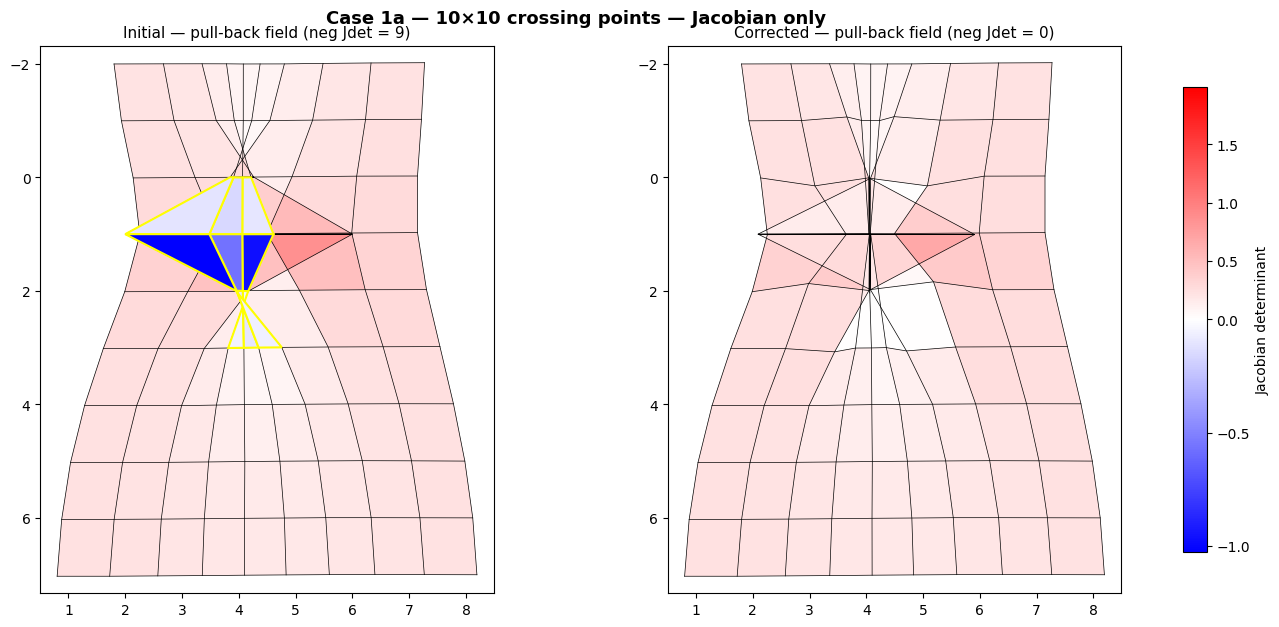

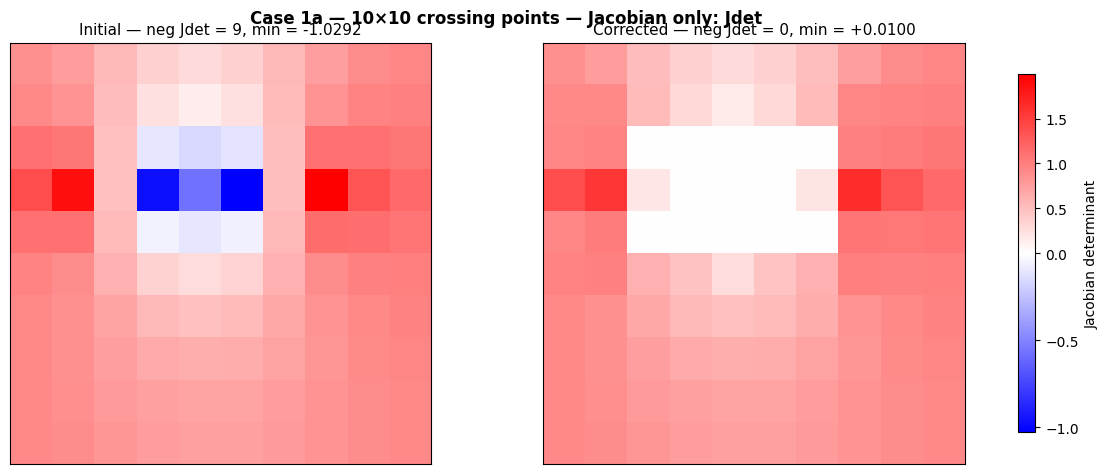

  Jac + Shoelace              0.08s  neg=  0  min_jdet=+0.010000  L2=3.0063  [Jac:OK  Shoe:OK  Tri:OK  h:OK  v:OK  d1:FAIL(7)  d2:OK  glob:OK]


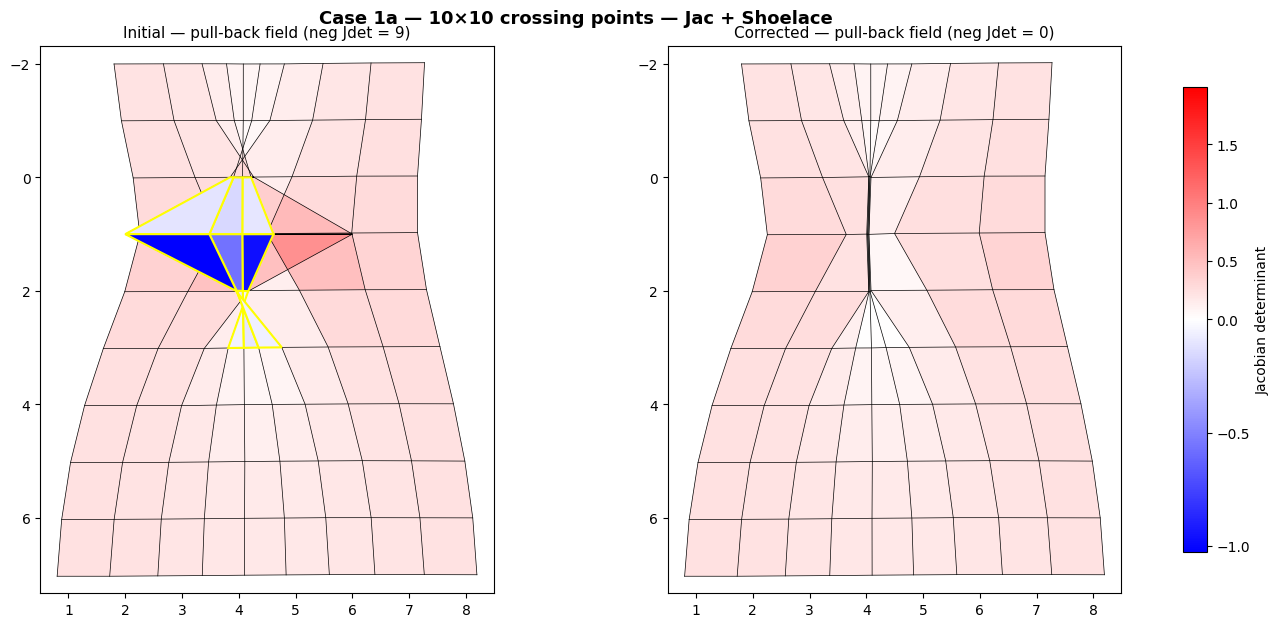

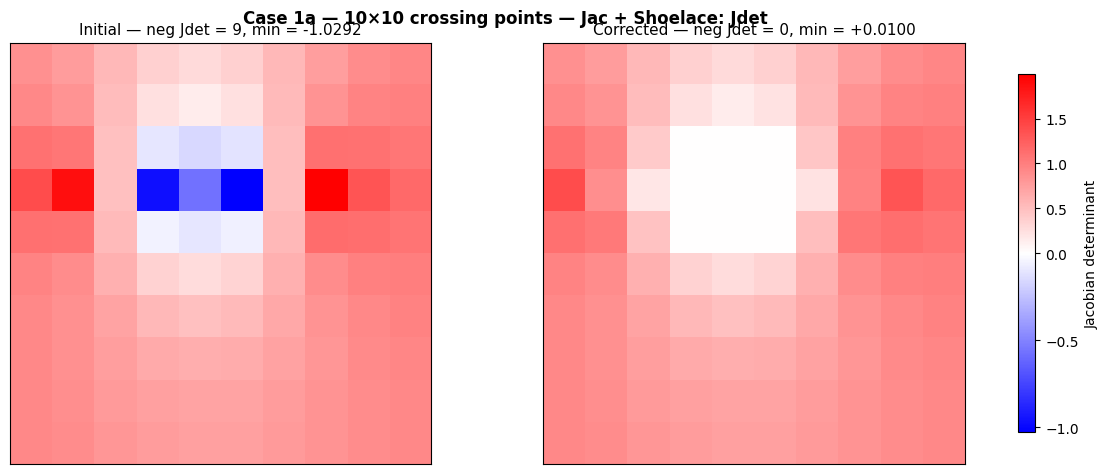

  Jac + Triangulated          0.12s  neg=  0  min_jdet=+0.019653  L2=3.0432  [Jac:OK  Shoe:OK  Tri:OK  h:OK  v:OK  d1:FAIL(6)  d2:OK  glob:OK]


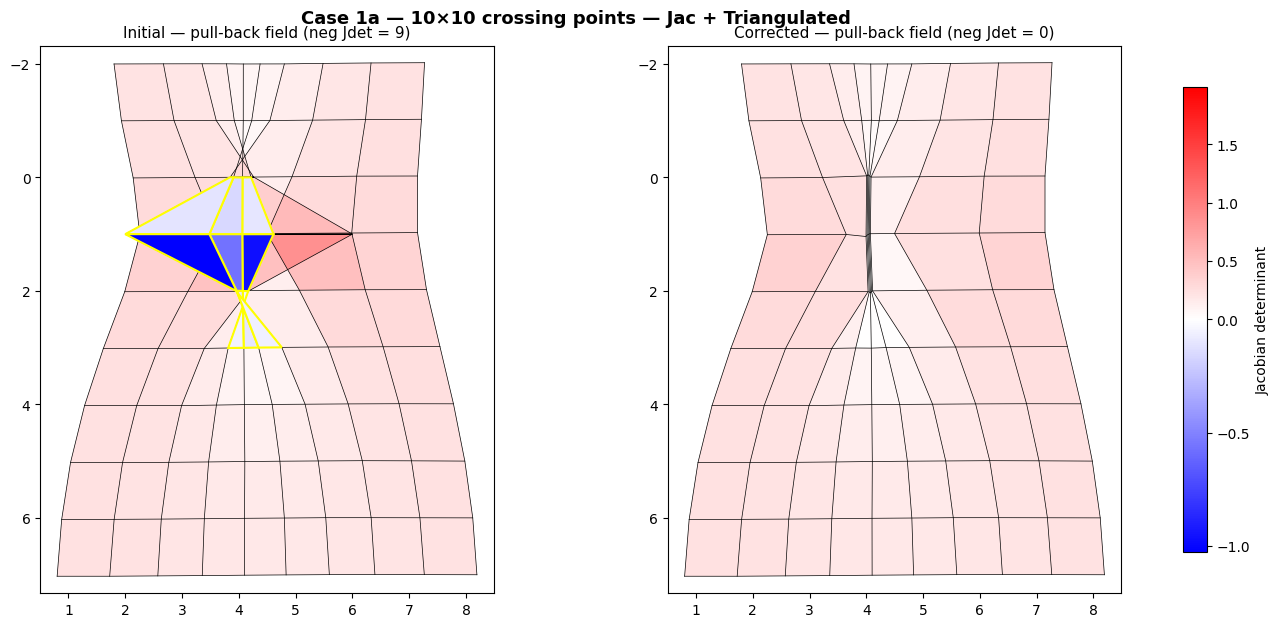

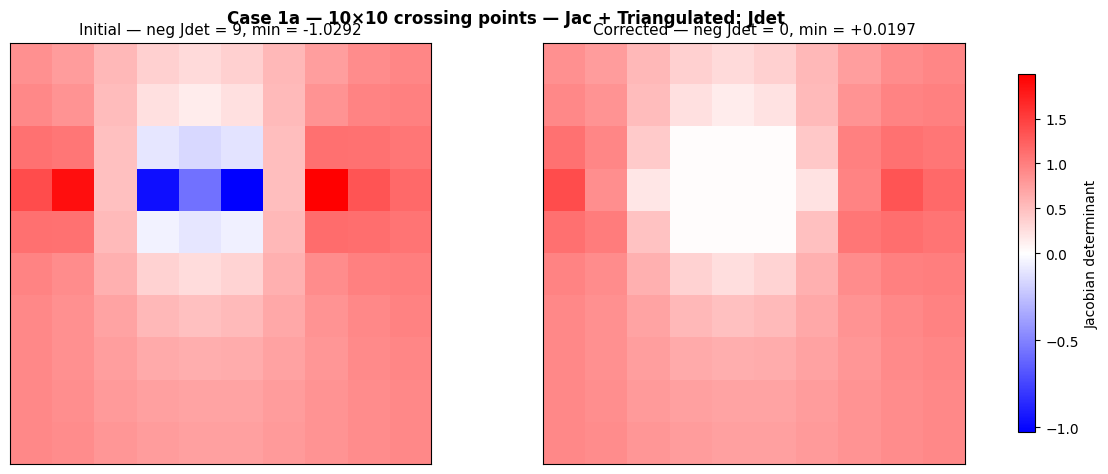

  Jac + Injectivity           0.02s  neg=  0  min_jdet=+0.299403  L2=4.3146  [Jac:OK  Shoe:OK  Tri:OK  h:OK  v:OK  d1:OK  d2:OK  glob:OK]


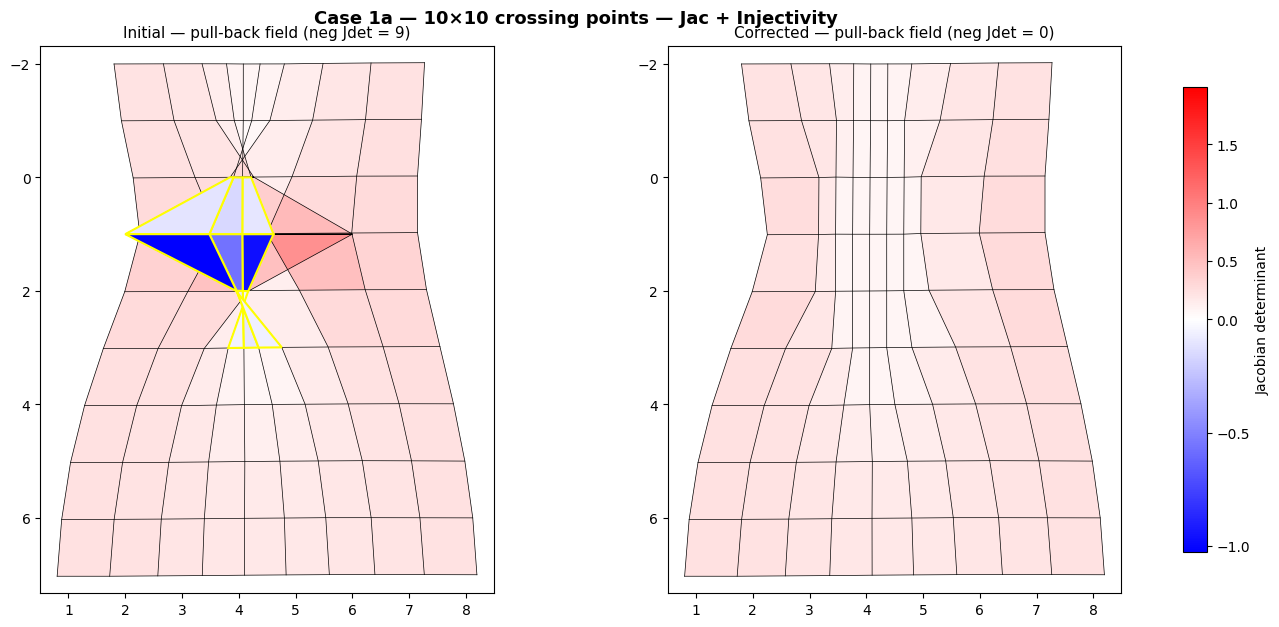

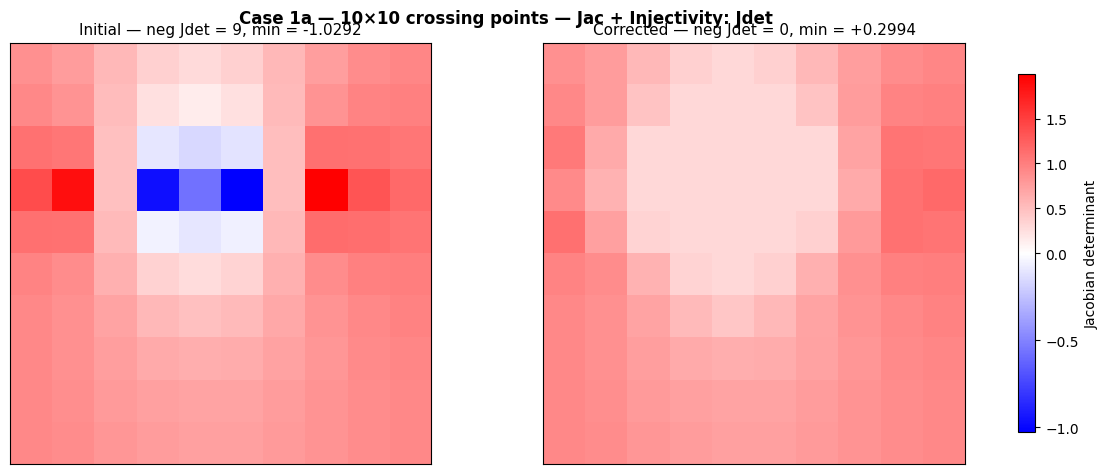

  All constraints             0.03s  neg=  0  min_jdet=+0.299403  L2=4.3146  [Jac:OK  Shoe:OK  Tri:OK  h:OK  v:OK  d1:OK  d2:OK  glob:OK]


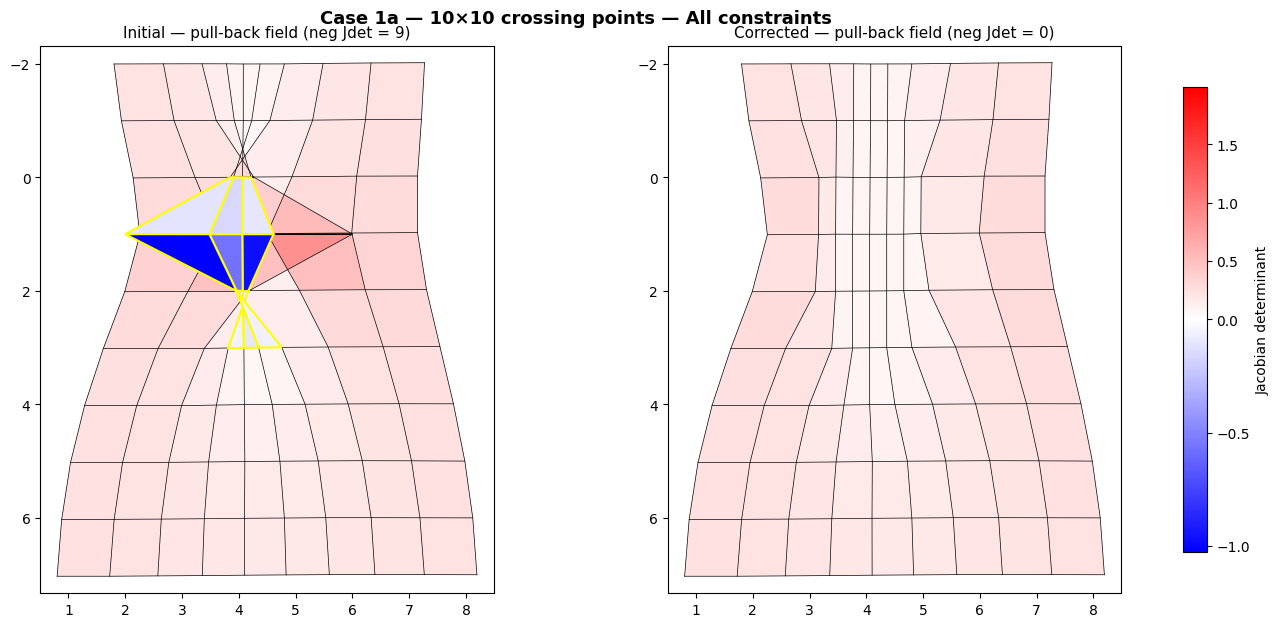

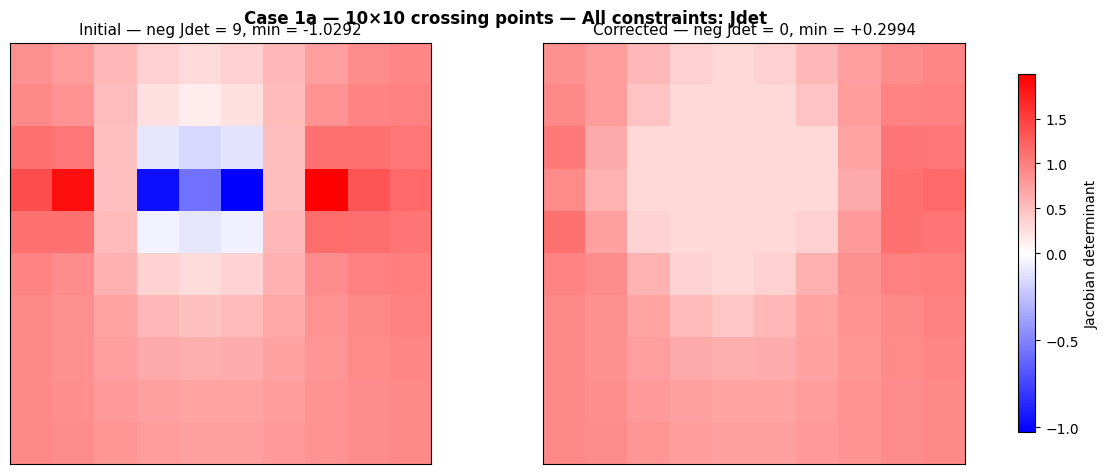

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A

  Case 1c — 20×40 edges  |  20x40  |  Initial neg-Jdet: 32
  Jacobian only               0.35s  neg=  0  min_jdet=+0.010000  L2=2.9745  [Jac:OK  Shoe:FAIL(27)  Tri:FAIL(51)  h:FAIL(14)  v:FAIL(15)  d1:FAIL(20)  d2:FAIL(21)  glob:INTERSECT]


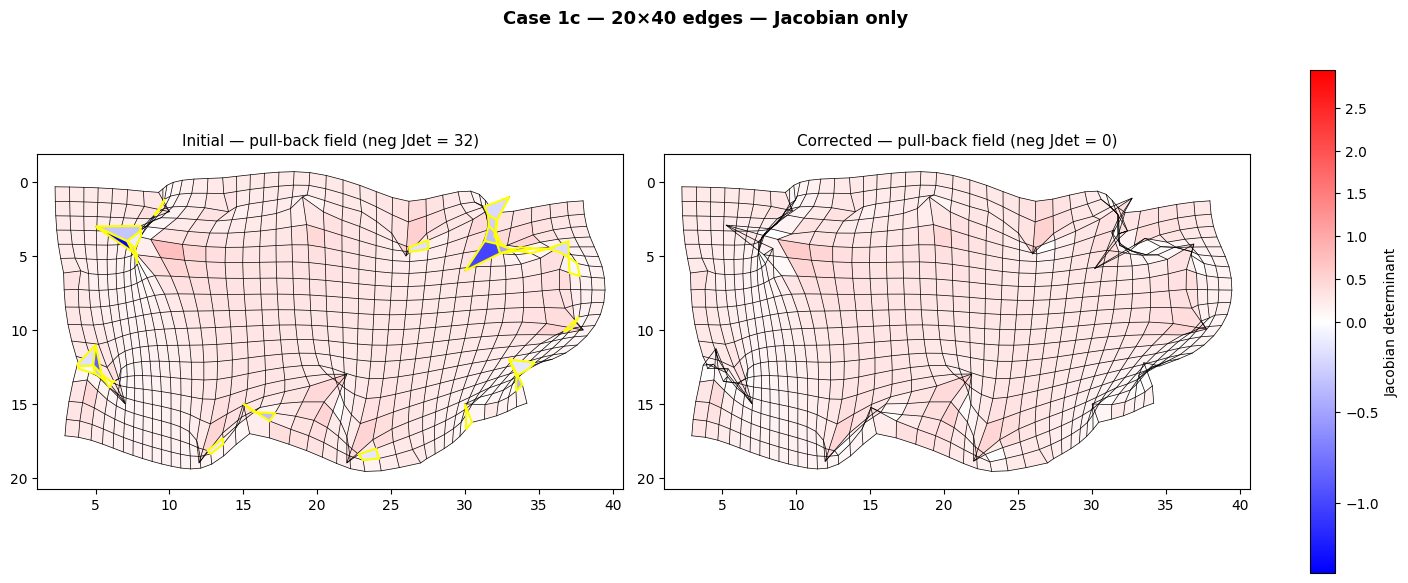

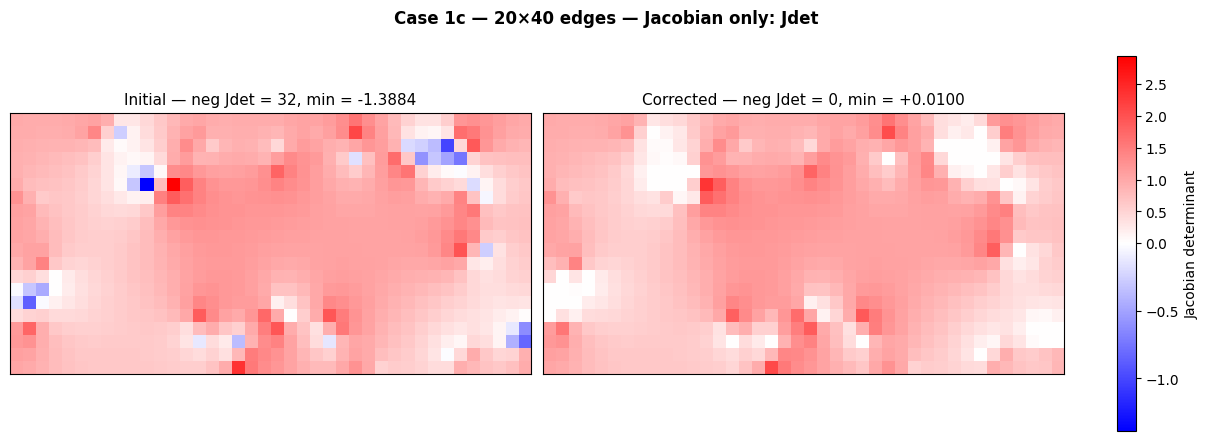

  Jac + Shoelace              0.44s  neg=  0  min_jdet=+0.010000  L2=3.9622  [Jac:OK  Shoe:OK  Tri:FAIL(55)  h:FAIL(14)  v:FAIL(17)  d1:FAIL(17)  d2:FAIL(19)  glob:INTERSECT]


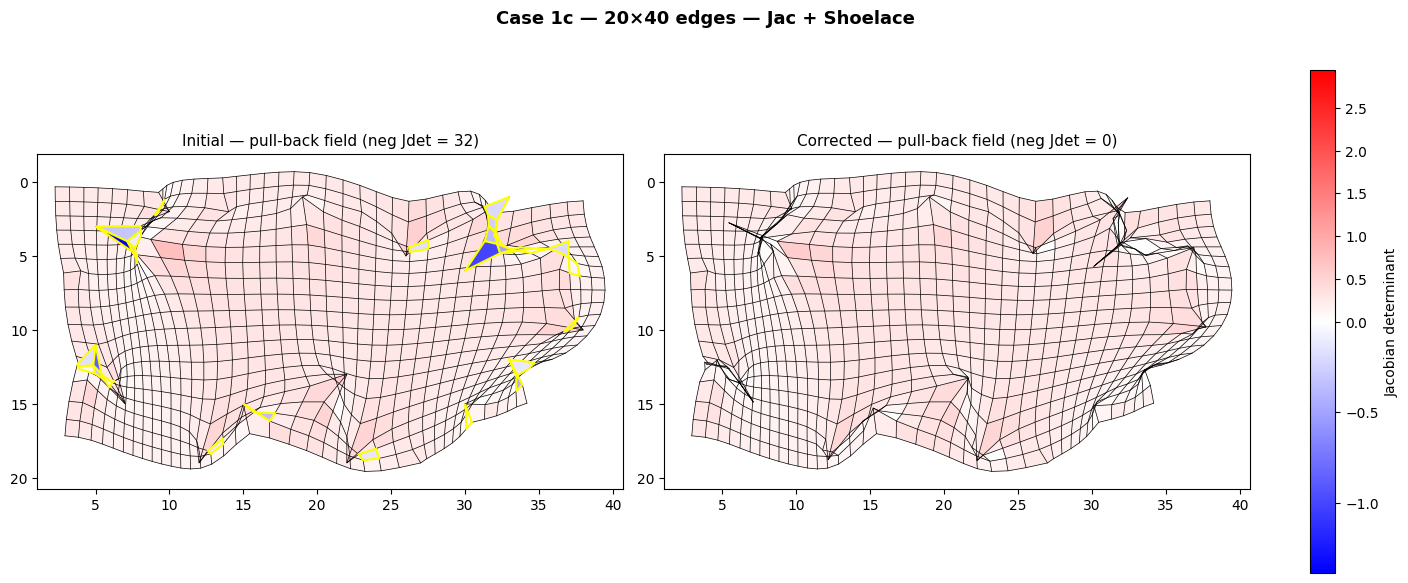

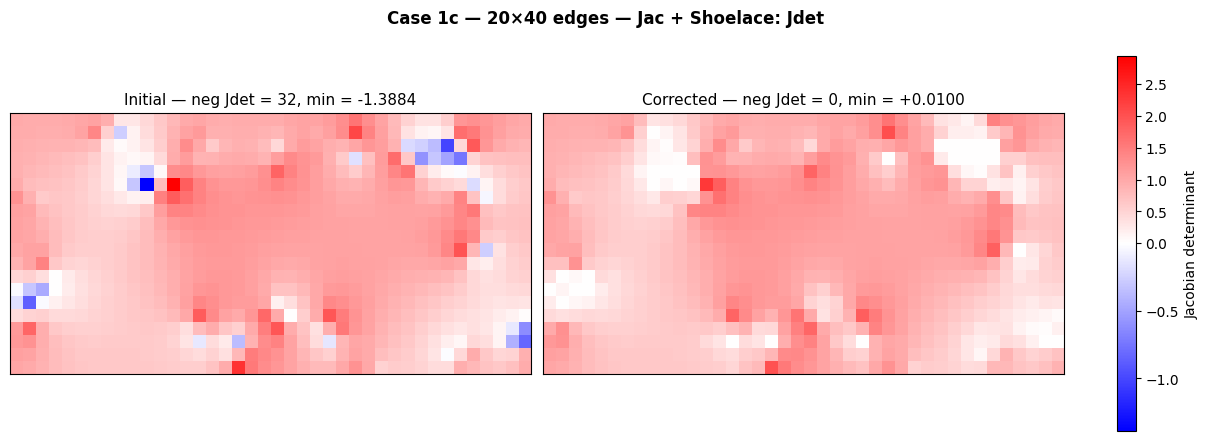

  Jac + Triangulated          6.97s  neg=  0  min_jdet=+0.010000  L2=5.6010  [Jac:OK  Shoe:OK  Tri:OK  h:FAIL(5)  v:FAIL(5)  d1:FAIL(13)  d2:FAIL(18)  glob:OK]


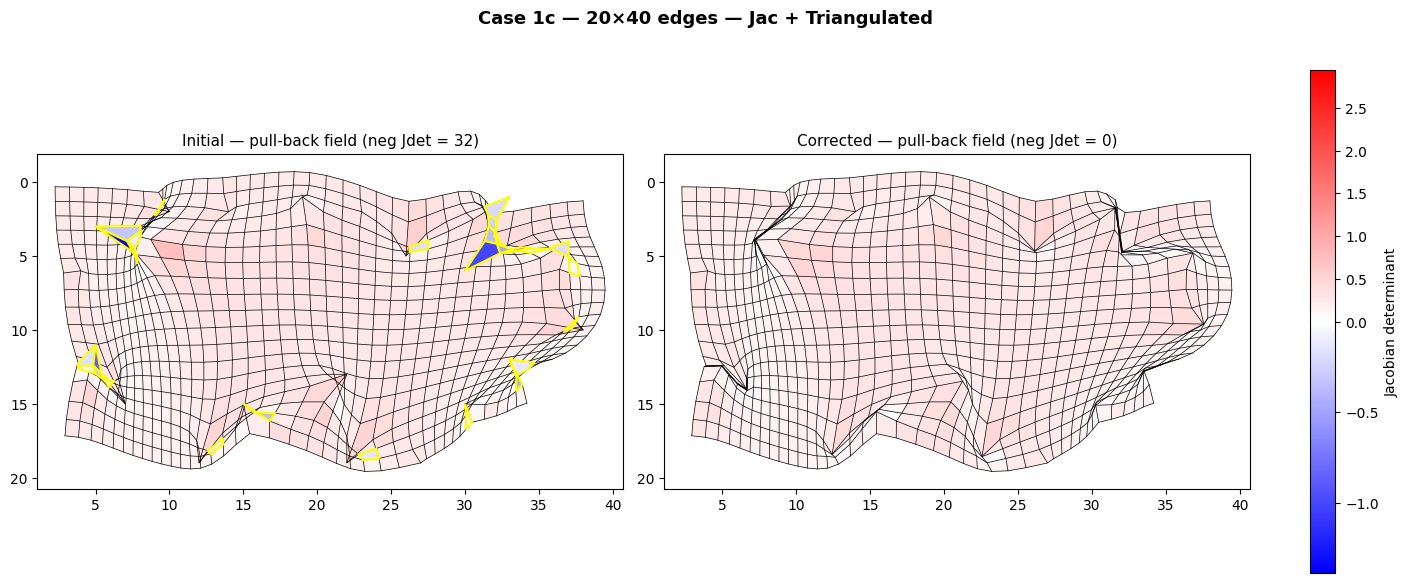

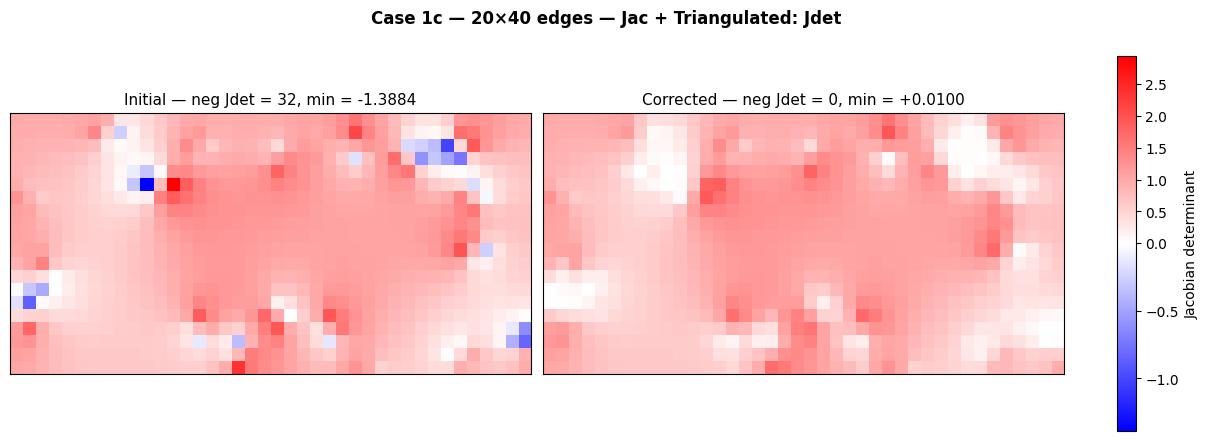

  Jac + Injectivity          13.62s  neg=  0  min_jdet=+0.010000  L2=8.0990  [Jac:OK  Shoe:FAIL(6)  Tri:FAIL(19)  h:OK  v:OK  d1:OK  d2:OK  glob:INTERSECT]


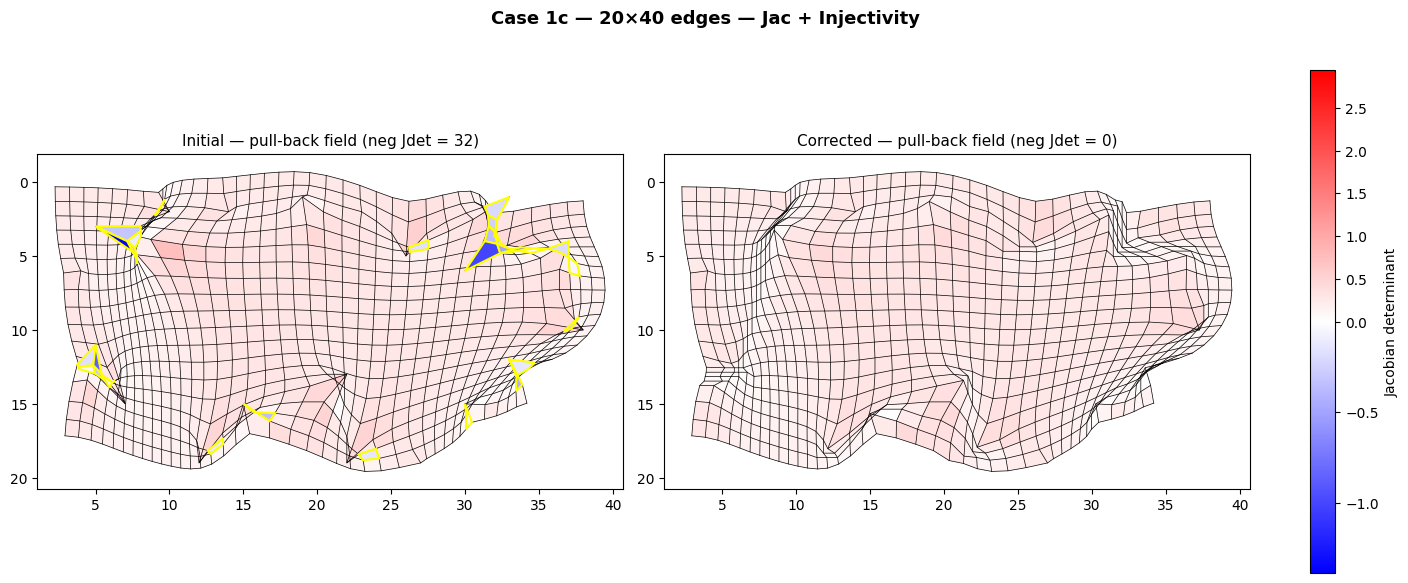

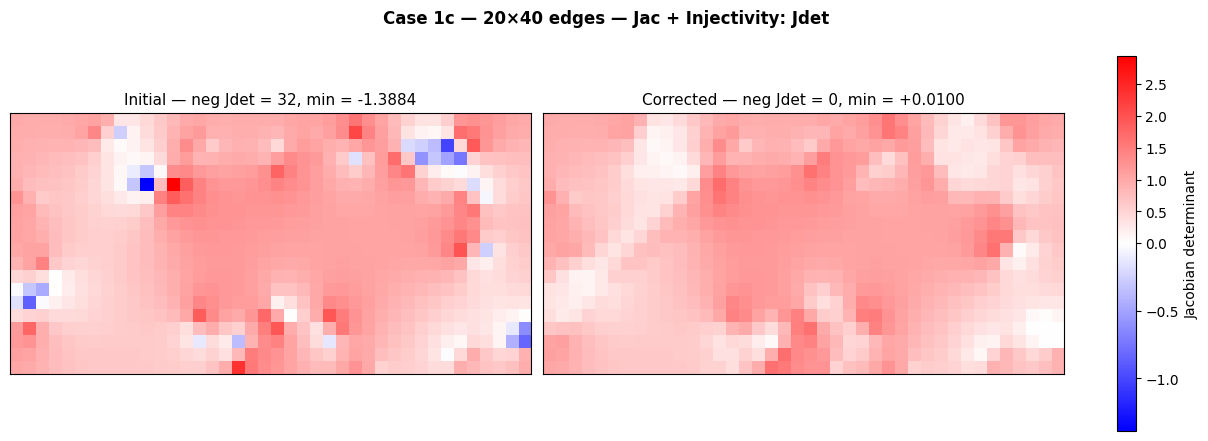

  All constraints            13.26s  neg=  0  min_jdet=+0.010000  L2=8.1968  [Jac:OK  Shoe:OK  Tri:OK  h:OK  v:OK  d1:OK  d2:OK  glob:OK]


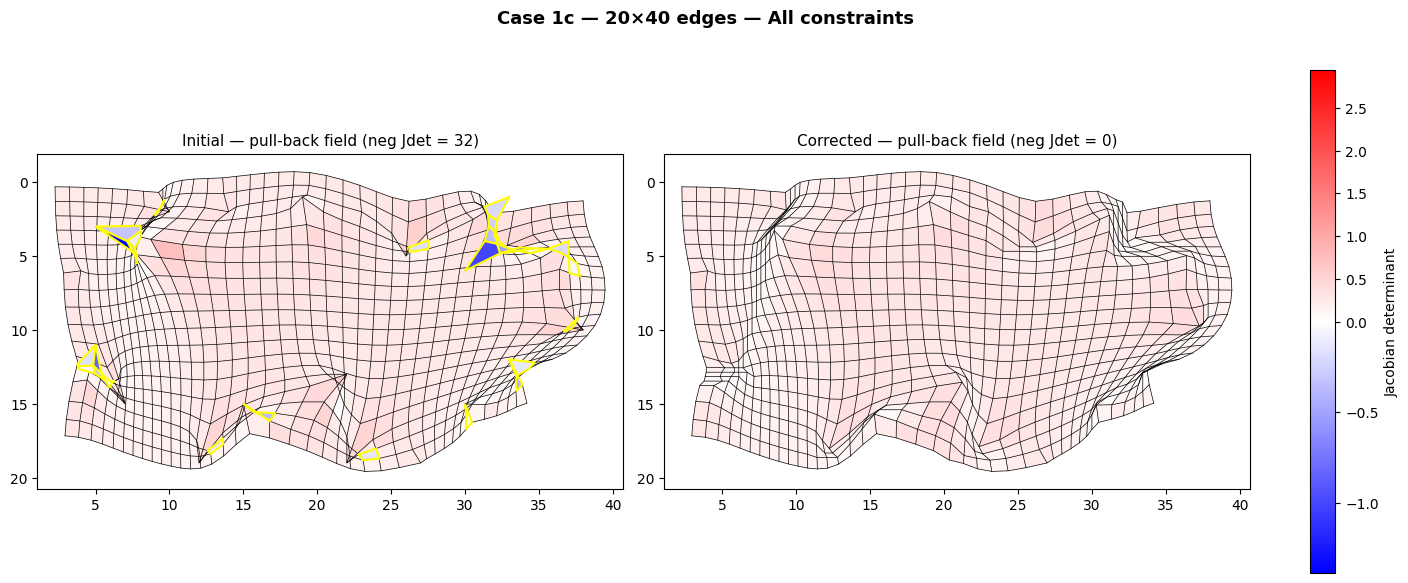

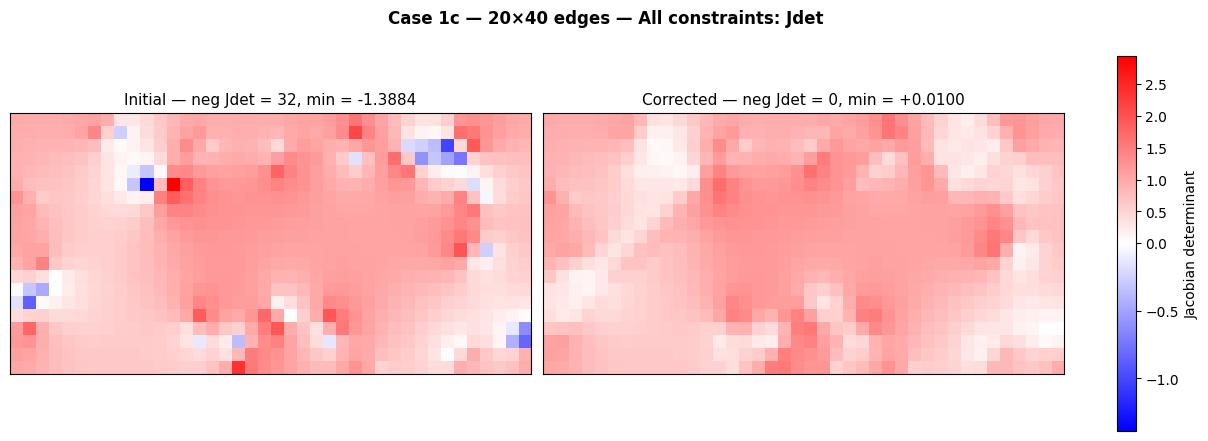

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A

  Case 3d — 20×20 crossing points  |  20x20  |  Initial neg-Jdet: 30
  Jacobian only               0.24s  neg=  0  min_jdet=+0.010000  L2=6.1242  [Jac:OK  Shoe:FAIL(48)  Tri:FAIL(63)  h:FAIL(25)  v:FAIL(6)  d1:FAIL(39)  d2:FAIL(9)  glob:INTERSECT]


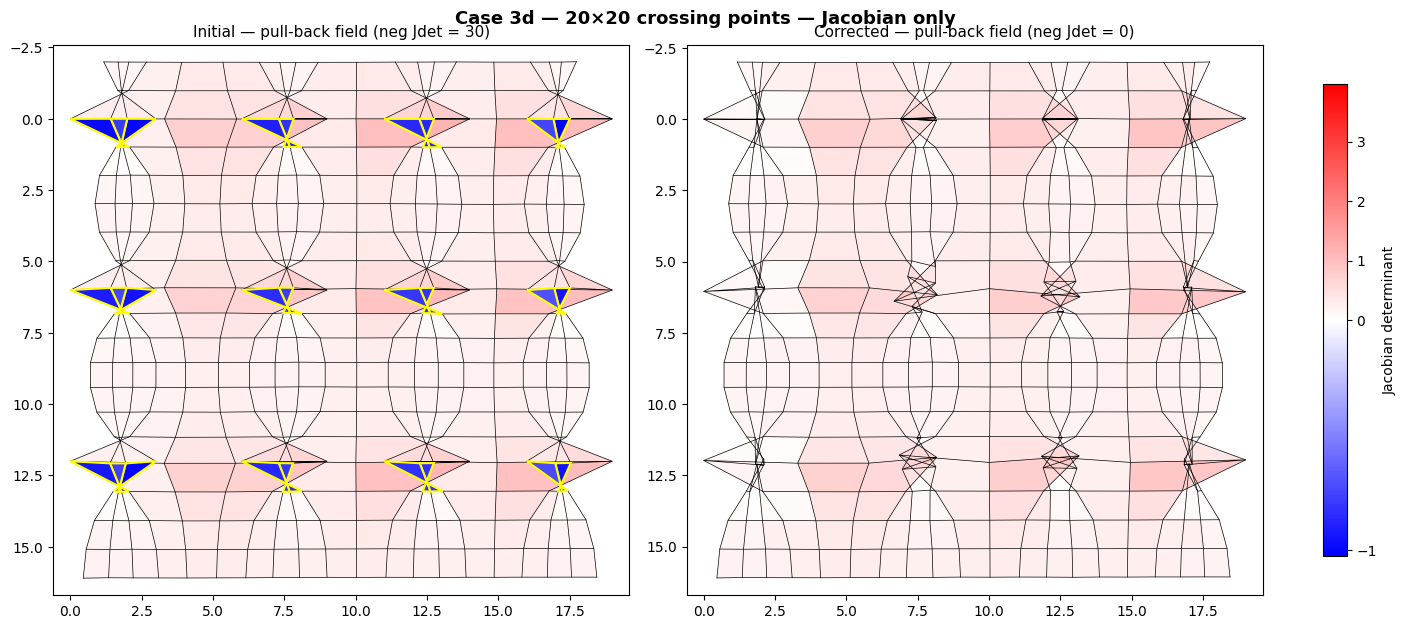

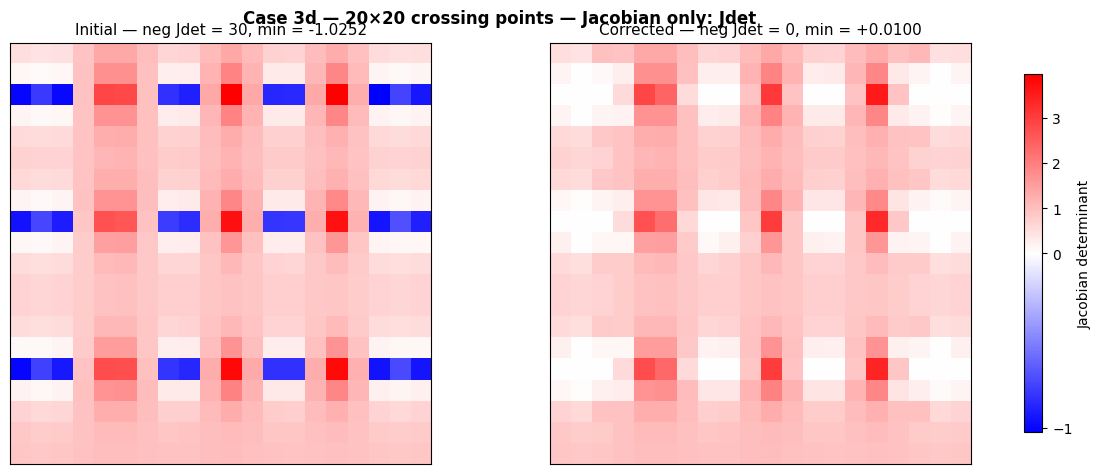

  Jac + Shoelace              3.99s  neg=  0  min_jdet=+0.010000  L2=7.0265  [Jac:OK  Shoe:OK  Tri:FAIL(54)  h:FAIL(30)  v:OK  d1:FAIL(28)  d2:OK  glob:INTERSECT]


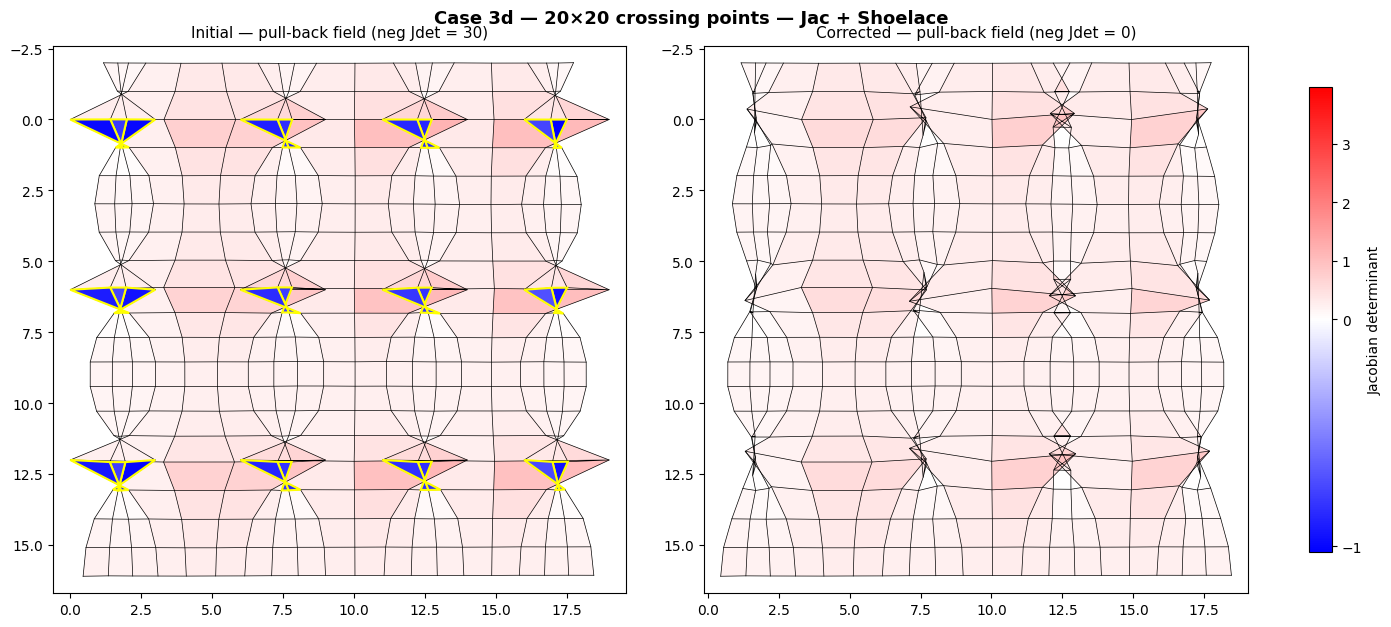

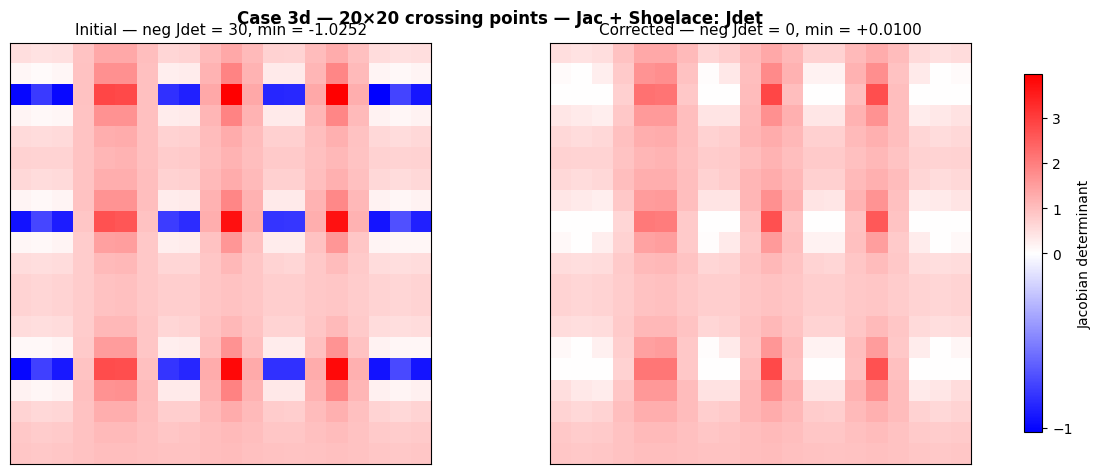

  Jac + Triangulated          5.65s  neg=  0  min_jdet=+0.010000  L2=7.5524  [Jac:OK  Shoe:OK  Tri:OK  h:FAIL(11)  v:OK  d1:FAIL(29)  d2:OK  glob:OK]


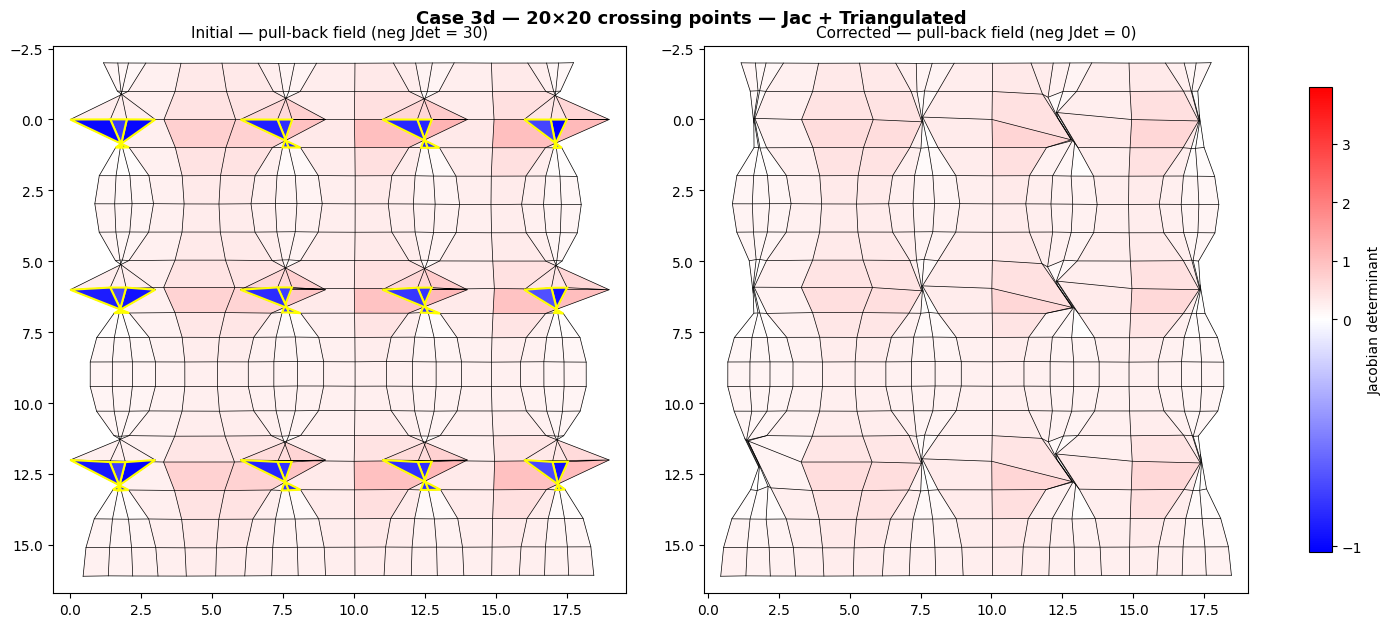

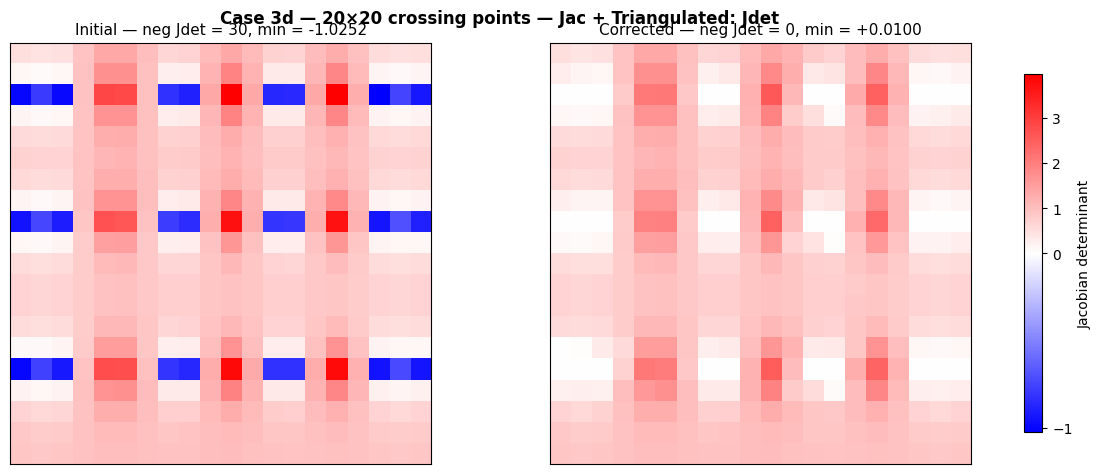

  Jac + Injectivity           0.95s  neg=  0  min_jdet=+0.248952  L2=9.8864  [Jac:OK  Shoe:OK  Tri:OK  h:OK  v:OK  d1:OK  d2:OK  glob:OK]


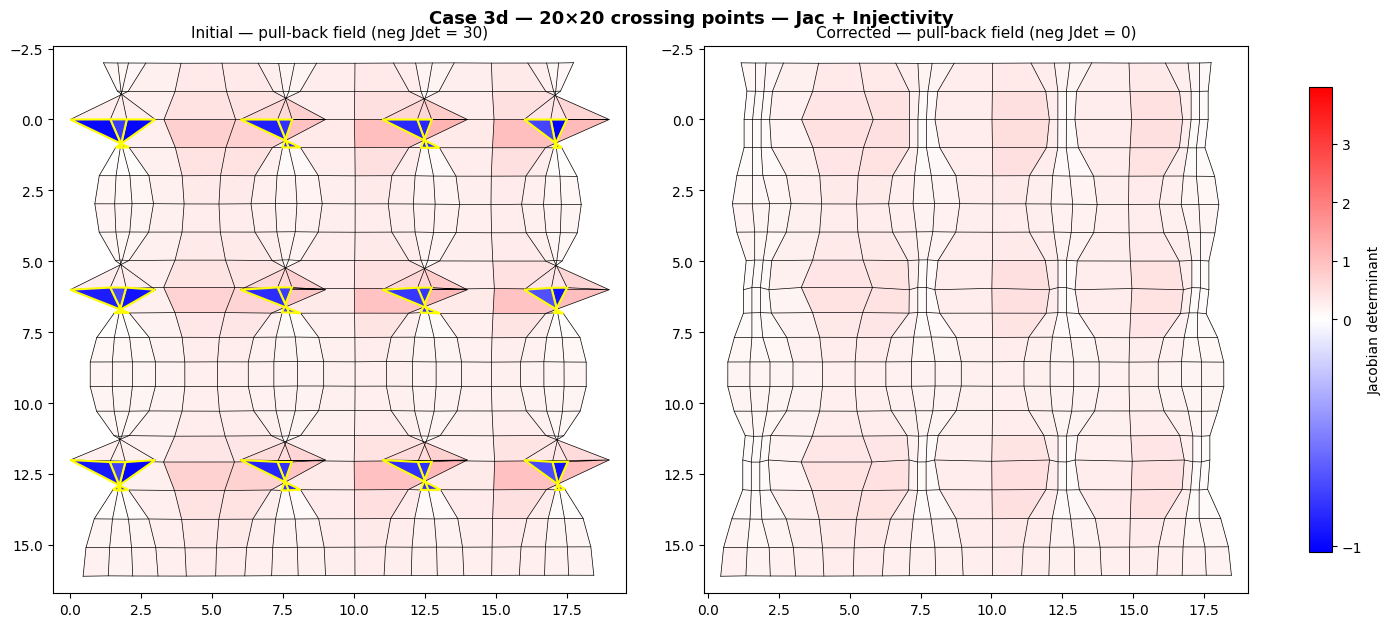

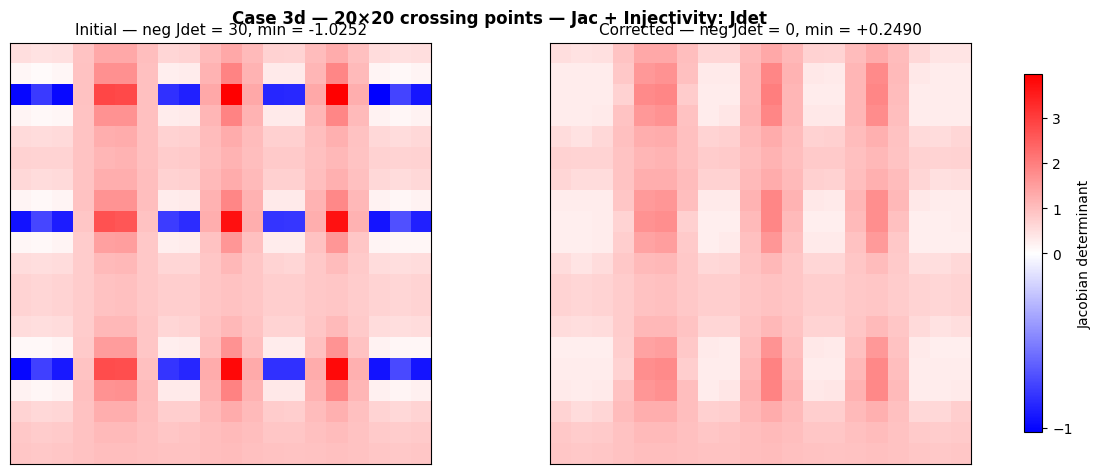

  All constraints             1.42s  neg=  0  min_jdet=+0.248952  L2=9.8864  [Jac:OK  Shoe:OK  Tri:OK  h:OK  v:OK  d1:OK  d2:OK  glob:OK]


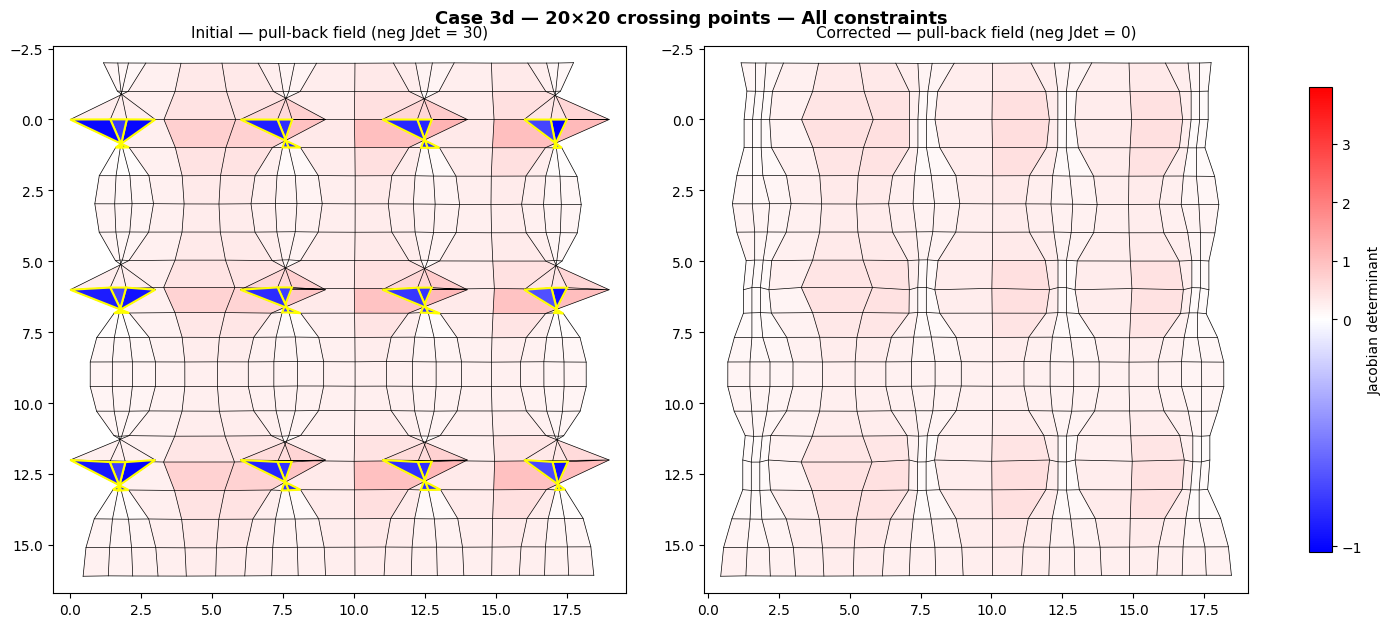

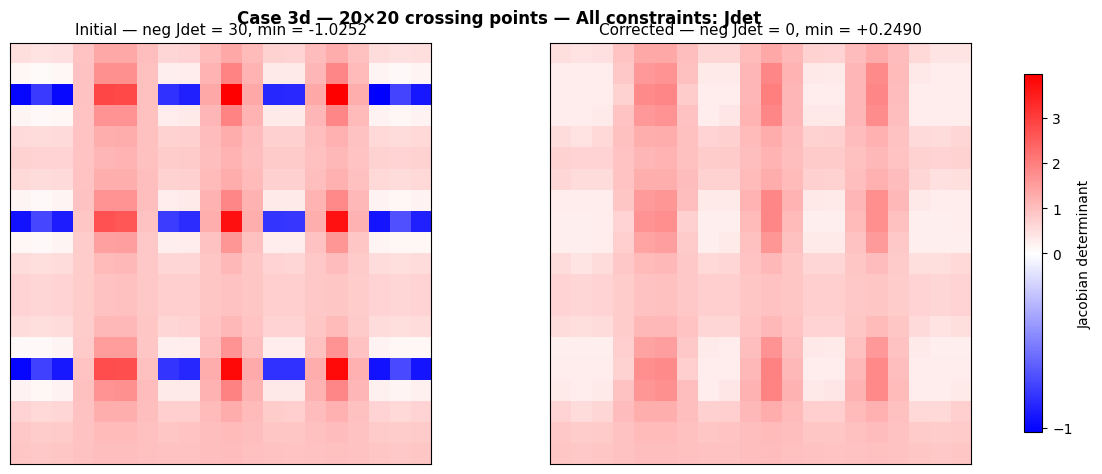

In [6]:
all_results = {}

# --- Synthetic correspondence cases ---
for key in ["01a_10x10_crossing", "01c_20x40_edges", "03d_20x20_crossing"]:
    deformation, ms, fs = make_deformation(key)
    title = SYNTHETIC_CASES[key]["title"]
    all_results[title] = run_case(deformation, title)


  Case 1e — 20×20 spirals  |  20x20  |  Initial neg-Jdet: 189
  Jacobian only              22.53s  neg=  0  min_jdet=+0.010000  L2=37.3509  [Jac:OK  Shoe:FAIL(117)  Tri:FAIL(171)  h:FAIL(104)  v:FAIL(94)  d1:FAIL(113)  d2:FAIL(109)  glob:INTERSECT]


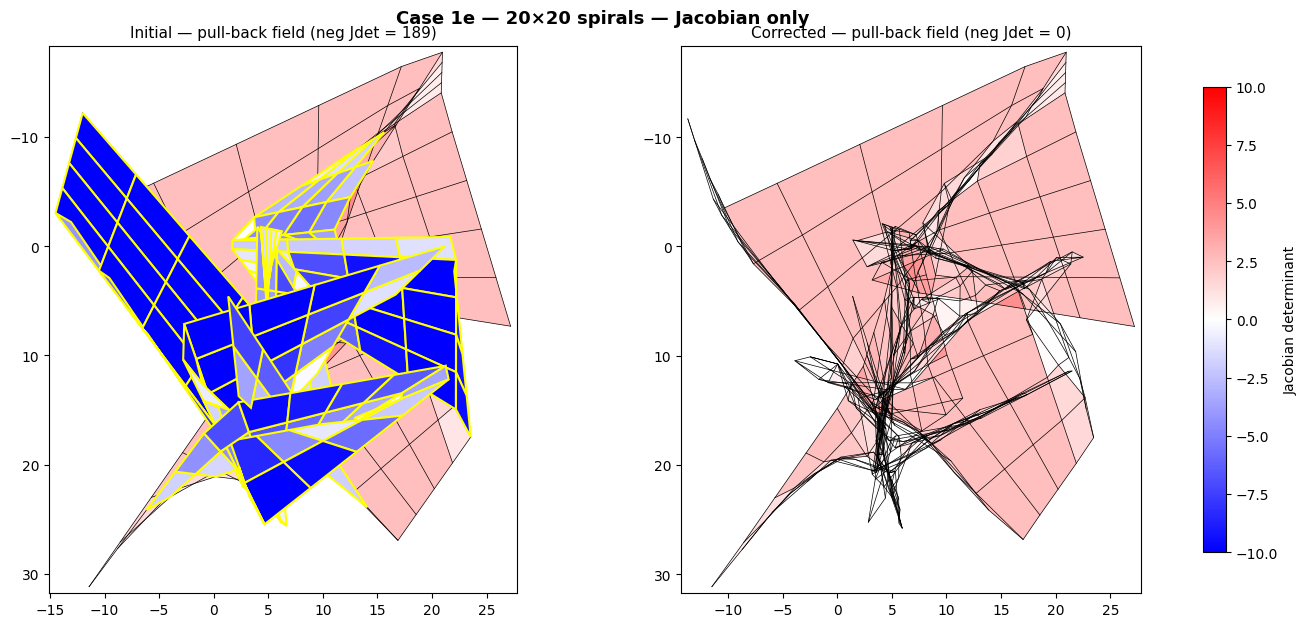

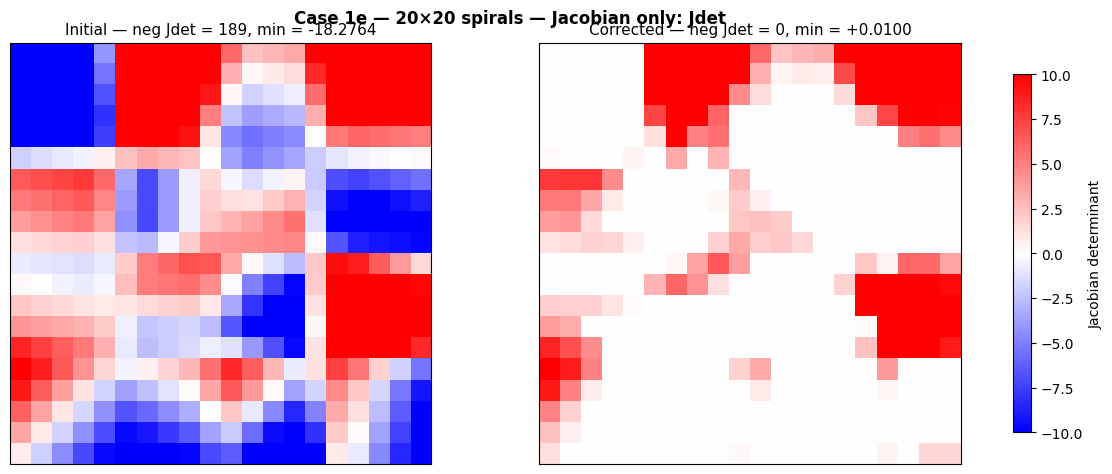

  Jac + Shoelace            237.99s  neg=  0  min_jdet=+0.010000  L2=40.5163  [Jac:OK  Shoe:OK  Tri:FAIL(199)  h:FAIL(111)  v:FAIL(92)  d1:FAIL(123)  d2:FAIL(111)  glob:INTERSECT]


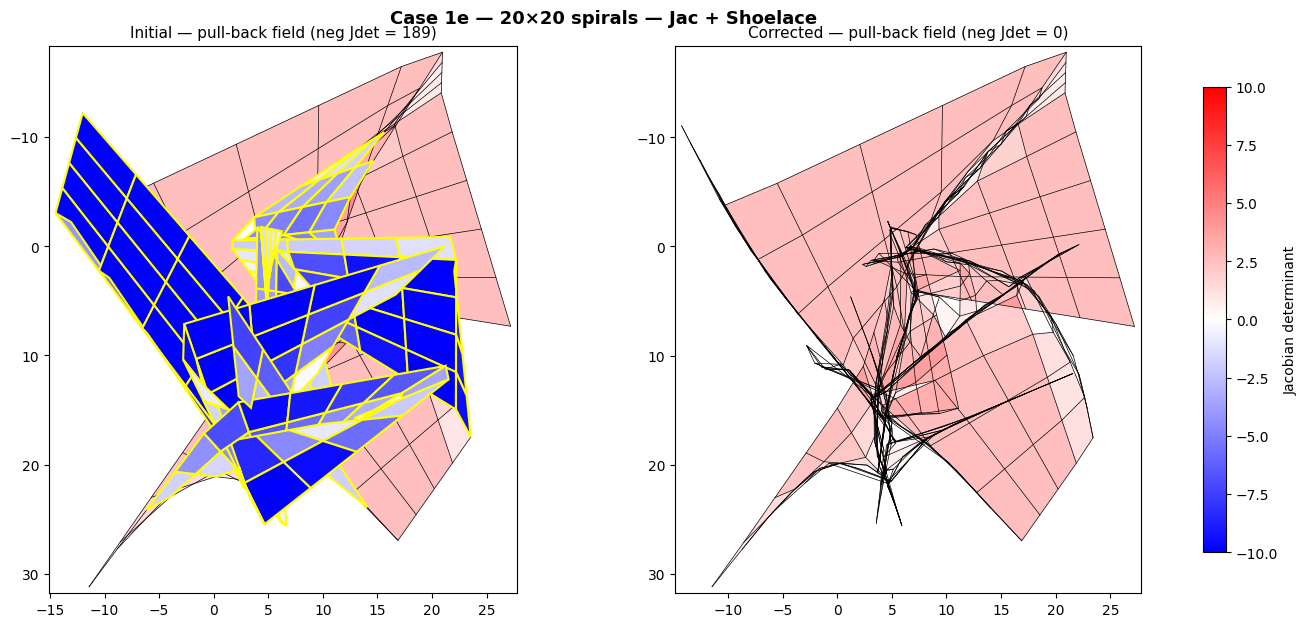

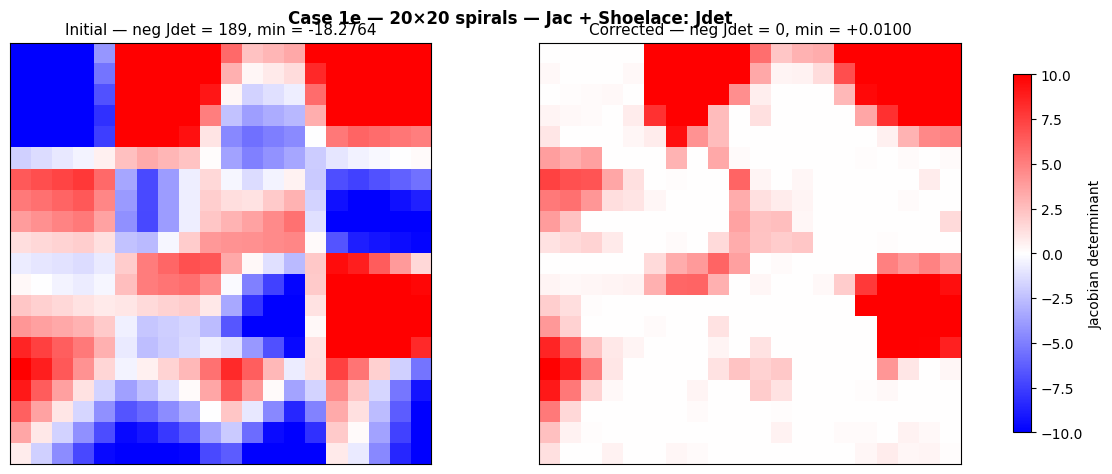

  Jac + Triangulated        389.49s  neg=  0  min_jdet=+0.010000  L2=44.3177  [Jac:OK  Shoe:OK  Tri:OK  h:FAIL(100)  v:FAIL(84)  d1:FAIL(128)  d2:FAIL(101)  glob:INTERSECT]


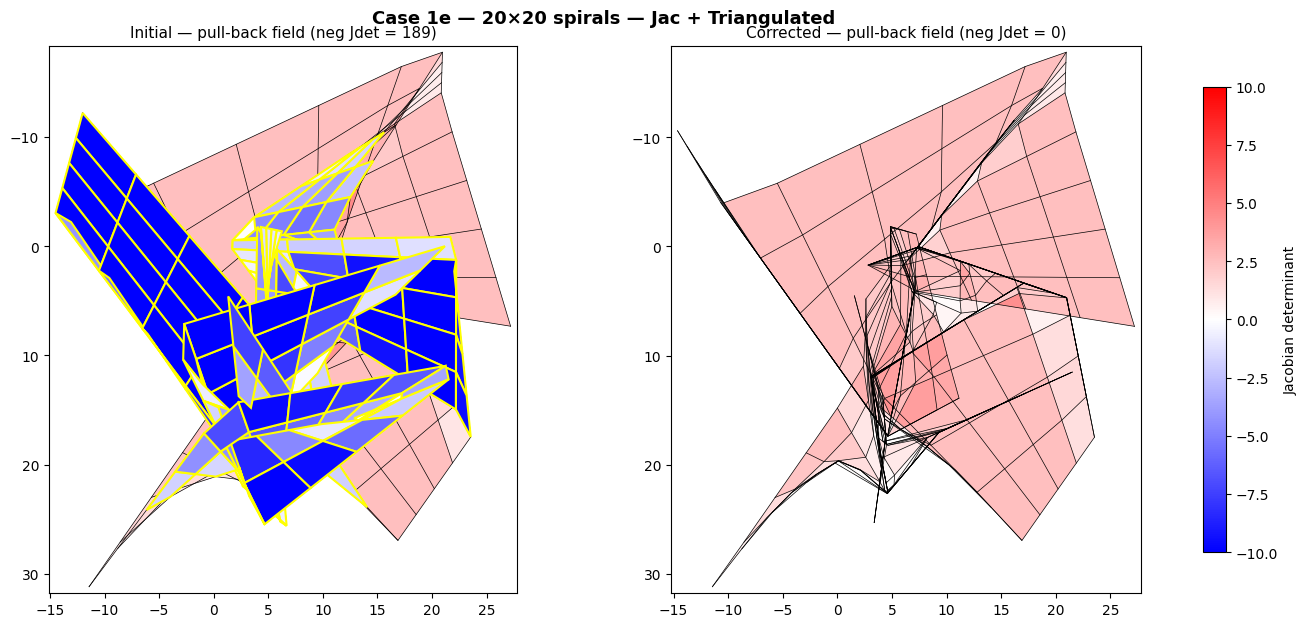

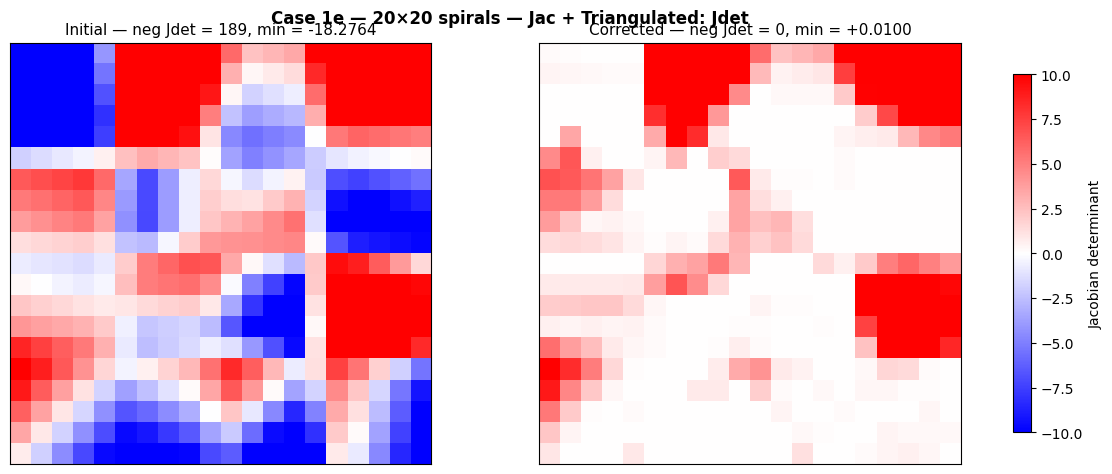

KeyboardInterrupt: 

In [7]:
# --- Random DVF cases ---
for key in ["01e_20x20_random_spirals", "01f_20x20_random_seed_42"]:
    deformation = make_random_dvf(key)
    from test_cases import RANDOM_DVF_CASES
    title = RANDOM_DVF_CASES[key]["title"]
    all_results[title] = run_case(deformation, title)

In [ ]:
# --- Real-data slice (if available) ---
import os

real_path = "../../../data/test_cases/02b_64x91_slice200.npy"
if os.path.exists(real_path):
    deformation = np.load(real_path)
    all_results["Real 64x91"] = run_case(deformation, "Real 64x91 slice 200")
else:
    print(f"Skipping real data â€” {real_path} not found")

---
## Summary Table

In [ ]:
mode_names = list(MODES.keys())

print(f"{'Test Case':<28s}", end="")
for m in mode_names:
    print(f"  {m:>20s}", end="")
print()
print("-" * (28 + 22 * len(mode_names)))

for label, results in all_results.items():
    # Time row
    print(f"{label:<28s}", end="")
    for m in mode_names:
        r = results[m]
        print(f"  {r['time']:>17.2f}s  ", end="")
    print("  (time)")

    # L2 row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        print(f"  {r['l2_err']:>18.4f} ", end="")
    print("  (L2)")

    # Min Jdet row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        print(f"  {r['final_min']:>+18.6f}", end="")
    print("  (min Jdet)")

    # Shoelace row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        v = r['n_neg_shoe']
        s = 'OK' if v == 0 else str(v)
        print(f"  {s:>18s} ", end="")
    print("  (Shoelace viol)")

    # Triangulated row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        v = r['n_neg_tri']
        s = 'OK' if v == 0 else str(v)
        print(f"  {s:>18s} ", end="")
    print("  (Tri viol)")

    # h-mono row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        v = r['n_h_viol']
        s = 'OK' if v == 0 else str(v)
        print(f"  {s:>18s} ", end="")
    print("  (h-mono viol)")

    # v-mono row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        v = r['n_v_viol']
        s = 'OK' if v == 0 else str(v)
        print(f"  {s:>18s} ", end="")
    print("  (v-mono viol)")

    # d1-mono row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        v = r['n_d1_viol']
        s = 'OK' if v == 0 else str(v)
        print(f"  {s:>18s} ", end="")
    print("  (d1-mono viol)")

    # d2-mono row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        v = r['n_d2_viol']
        s = 'OK' if v == 0 else str(v)
        print(f"  {s:>18s} ", end="")
    print("  (d2-mono viol)")

    # Global intersection row
    print(f"{'':28s}", end="")
    for m in mode_names:
        r = results[m]
        s = 'INTERSECT' if r['global_intersect'] else 'OK'
        print(f"  {s:>18s} ", end="")
    print("  (Glob intersect)")

    print()

## Plots

In [ ]:
# --- Bar chart: runtime by mode ---
case_labels = list(all_results.keys())
x = np.arange(len(case_labels))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 5))
for i, m in enumerate(mode_names):
    times = [all_results[c][m]["time"] for c in case_labels]
    ax.bar(x + i * width, times, width, label=m)

ax.set_ylabel("Time (s)")
ax.set_title("Runtime by Constraint Mode")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(case_labels, rotation=25, ha="right")
ax.legend()
plt.tight_layout()
show_and_save(OUTPUT_DIR)


In [ ]:
# --- Bar chart: L2 error by mode ---
fig, ax = plt.subplots(figsize=(12, 5))
for i, m in enumerate(mode_names):
    l2s = [all_results[c][m]["l2_err"] for c in case_labels]
    ax.bar(x + i * width, l2s, width, label=m)

ax.set_ylabel("L2 Error")
ax.set_title("L2 Deviation by Constraint Mode")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(case_labels, rotation=25, ha="right")
ax.legend()
plt.tight_layout()
show_and_save(OUTPUT_DIR)


In [ ]:
# --- Scatter: runtime vs L2 (Pareto front) ---
fig, ax = plt.subplots(figsize=(8, 6))
markers = ["o", "s", "^", "D"]

for i, m in enumerate(mode_names):
    times = [all_results[c][m]["time"] for c in case_labels]
    l2s = [all_results[c][m]["l2_err"] for c in case_labels]
    ax.scatter(times, l2s, marker=markers[i], s=80, label=m, zorder=3)

ax.set_xlabel("Time (s)")
ax.set_ylabel("L2 Error")
ax.set_title("Runtime vs L2 Error â€” Constraint Modes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
show_and_save(OUTPUT_DIR)


In [ ]:
# --- Heatmap: min Jdet by test case x mode ---
min_jdet_matrix = np.array([
    [all_results[c][m]["final_min"] for m in mode_names]
    for c in case_labels
])

fig, ax = plt.subplots(figsize=(10, max(3, 0.6 * len(case_labels))))
im = ax.imshow(min_jdet_matrix, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=25, ha="right")
ax.set_yticks(range(len(case_labels)))
ax.set_yticklabels(case_labels, fontsize=9)
for i in range(len(case_labels)):
    for j in range(len(mode_names)):
        val = min_jdet_matrix[i, j]
        color = "white" if val < 0 else "black"
        ax.text(j, i, f"{val:+.4f}", ha="center", va="center", fontsize=8, color=color)
fig.colorbar(im, ax=ax, label="Min Jacobian determinant")
ax.set_title("Final Min Jdet -- Test Case x Constraint Mode")
plt.tight_layout()
show_and_save(OUTPUT_DIR)


In [ ]:
# --- Remaining neg-Jdet pixels by mode (convergence success) ---
neg_matrix = np.array([
    [all_results[c][m]["final_neg"] for m in mode_names]
    for c in case_labels
])

fig, ax = plt.subplots(figsize=(10, max(3, 0.6 * len(case_labels))))
cmap = plt.cm.colors.ListedColormap(["#2ecc71", "#e74c3c"])
bounds = [-0.5, 0.5, neg_matrix.max() + 0.5]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(neg_matrix, cmap=cmap, norm=norm, aspect="auto")
ax.set_xticks(range(len(mode_names)))
ax.set_xticklabels(mode_names, rotation=25, ha="right")
ax.set_yticks(range(len(case_labels)))
ax.set_yticklabels(case_labels, fontsize=9)
for i in range(len(case_labels)):
    for j in range(len(mode_names)):
        val = neg_matrix[i, j]
        ax.text(j, i, str(val), ha="center", va="center", fontsize=10,
                fontweight="bold", color="white")
ax.set_title("Remaining Neg-Jdet Pixels (green=0, red=failed)")
plt.tight_layout()
show_and_save(OUTPUT_DIR)


In [ ]:
# --- Runtime overhead relative to Jacobian-only baseline ---
baseline_mode = "Jacobian only"
other_modes = [m for m in mode_names if m != baseline_mode]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(case_labels))
width = 0.25

for i, m in enumerate(other_modes):
    overhead = []
    for c in case_labels:
        base_t = all_results[c][baseline_mode]["time"]
        mode_t = all_results[c][m]["time"]
        overhead.append(mode_t / base_t if base_t > 0 else 1.0)
    ax.bar(x + i * width, overhead, width, label=m)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Baseline (Jac only)")
ax.set_xticks(x + width)
ax.set_xticklabels(case_labels, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Runtime multiplier vs Jacobian-only")
ax.set_title("Constraint Overhead (1.0 = same as Jacobian-only)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
show_and_save(OUTPUT_DIR)


In [ ]:
# --- Save results ---
if 'results' in dir() and isinstance(results, dict) and results:
    rows, cols = results_to_rows(results)
    save_results_csv(rows, cols, OUTPUT_DIR)
    summary = log_run_footer(summary, results)
    save_summary_json(summary, OUTPUT_DIR)
elif 'mag_results' in dir():
    rows, cols = results_to_rows(mag_results)
    save_results_csv(rows, cols, OUTPUT_DIR, name='results_magnitude')
    if 'density_results' in dir():
        rows2, cols2 = results_to_rows(density_results)
        save_results_csv(rows2, cols2, OUTPUT_DIR, name='results_density')
    combined = {**mag_results, **density_results} if 'density_results' in dir() else mag_results
    summary = log_run_footer(summary, combined)
    save_summary_json(summary, OUTPUT_DIR)
else:
    save_summary_json(summary, OUTPUT_DIR)
    print('No results dict found; saved summary only.')
